# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

In [1]:
# Cargar todas las librerías

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from math import factorial
from scipy import stats as st

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames

calls = pd.read_csv('megaline_calls.csv', sep=',')

internet = pd.read_csv('megaline_internet.csv', sep=',')

messages = pd.read_csv('megaline_messages.csv',sep=',')

plans = pd.read_csv('megaline_plans.csv',sep=',')

users = pd.read_csv('megaline_users.csv',sep=',')

## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

print('Las tarifas de los planes son:')
plans.info()

Las tarifas de los planes son:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas

print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


No se aprecian valores ausentes, considero que los valores de las tablas corresponden a la tipo de dato.

## Corregir datos

In [5]:
print('Tenemos datos ausentes: ',plans.isna().sum())
print()
print('Tenemos duplicados: ',plans.duplicated().sum())

Tenemos datos ausentes:  messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

Tenemos duplicados:  0


## Enriquecer los datos

## Usuarios/as

In [6]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [7]:
# Imprime una muestra de datos para usuarios

print(users)

     user_id first_name   last_name  age  \
0       1000   Anamaria       Bauer   45   
1       1001     Mickey   Wilkerson   28   
2       1002     Carlee     Hoffman   36   
3       1003   Reynaldo     Jenkins   52   
4       1004    Leonila    Thompson   40   
..       ...        ...         ...  ...   
495     1495      Fidel      Sharpe   67   
496     1496      Ariel    Shepherd   49   
497     1497      Donte     Barrera   49   
498     1498       Scot  Williamson   51   
499     1499      Shena     Dickson   37   

                                          city    reg_date      plan  \
0        Atlanta-Sandy Springs-Roswell, GA MSA  2018-12-24  ultimate   
1              Seattle-Tacoma-Bellevue, WA MSA  2018-08-13      surf   
2         Las Vegas-Henderson-Paradise, NV MSA  2018-10-21      surf   
3                                Tulsa, OK MSA  2018-01-28      surf   
4              Seattle-Tacoma-Bellevue, WA MSA  2018-05-23      surf   
..                                     

No encontré duplicados pero si valores ausentes que corresponden a los usuarios que se encuentran activos, decidí rellenar los huecos con la palabra activo para indentificarlos.

### Corregir los datos

In [8]:
print("Tenemos datos ausentes: ",users.isna().sum())
print()
print('Tenemos datos duplicados: ',users.duplicated().sum())

Tenemos datos ausentes:  user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

Tenemos datos duplicados:  0


### Enriquecer los datos

In [9]:
users['churn_date'] = users['churn_date'].fillna('activo').inplace=True
users['reg_date'] = pd.to_datetime(users['reg_date'] ,errors='coerce')

## Llamadas

In [10]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [11]:
# Imprime una muestra de datos para las llamadas

print(calls)

              id  user_id   call_date  duration
0        1000_93     1000  2018-12-27      8.52
1       1000_145     1000  2018-12-27     13.66
2       1000_247     1000  2018-12-27     14.48
3       1000_309     1000  2018-12-28      5.76
4       1000_380     1000  2018-12-30      4.22
...          ...      ...         ...       ...
137730  1499_199     1499  2018-11-21      8.72
137731  1499_200     1499  2018-10-20     10.89
137732  1499_201     1499  2018-09-21      8.12
137733  1499_202     1499  2018-10-10      0.37
137734  1499_203     1499  2018-12-29     13.86

[137735 rows x 4 columns]


Las columnas corresponden a los tipos de datos hallados, no existen duplicados ni datos ausentes

### Corregir los datos

In [12]:
print('Tenemos duplicados: ',calls.duplicated().sum())
print('Tenemos datos ausentes: ',calls.isna().sum())

Tenemos duplicados:  0
Tenemos datos ausentes:  id           0
user_id      0
call_date    0
duration     0
dtype: int64


### Enriquecer los datos

In [13]:
calls['call_date'] = pd.to_datetime(calls['call_date'] ,errors='coerce')

## Mensajes

In [14]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [15]:
# Imprime una muestra de datos para los mensajes

print(messages)

             id  user_id message_date
0      1000_125     1000   2018-12-27
1      1000_160     1000   2018-12-31
2      1000_223     1000   2018-12-31
3      1000_251     1000   2018-12-27
4      1000_255     1000   2018-12-26
...         ...      ...          ...
76046  1497_526     1497   2018-12-24
76047  1497_536     1497   2018-12-24
76048  1497_547     1497   2018-12-31
76049  1497_558     1497   2018-12-24
76050  1497_613     1497   2018-12-23

[76051 rows x 3 columns]


Las columnas corresponden a los tipos de datos hallados, no existen duplicados ni datos ausentes

### Corregir los datos

In [16]:
print('Tenemos duplicados: ',messages.duplicated().sum())
print('Tenemos datos ausentes: ',messages.isna().sum())

Tenemos duplicados:  0
Tenemos datos ausentes:  id              0
user_id         0
message_date    0
dtype: int64


### Enriquecer los datos

In [17]:
messages['message_date'] = pd.to_datetime(messages['message_date'], errors='coerce')

## Internet

In [18]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [19]:
# Imprime una muestra de datos para el tráfico de internet

print(internet)

              id  user_id session_date  mb_used
0        1000_13     1000   2018-12-29    89.86
1       1000_204     1000   2018-12-31     0.00
2       1000_379     1000   2018-12-28   660.40
3       1000_413     1000   2018-12-26   270.99
4       1000_442     1000   2018-12-27   880.22
...          ...      ...          ...      ...
104820  1499_215     1499   2018-10-20   218.06
104821  1499_216     1499   2018-12-30   304.72
104822  1499_217     1499   2018-09-22   292.75
104823  1499_218     1499   2018-12-07     0.00
104824  1499_219     1499   2018-12-24   758.31

[104825 rows x 4 columns]


Las columnas corresponden a los tipos de datos hallados, no existen duplicados ni datos ausentes

### Corregir los datos

In [20]:
print('Tenemos duplicados: ',internet.duplicated().sum())
print('Tenemos datos ausentes: ',internet.isna().sum())

Tenemos duplicados:  0
Tenemos datos ausentes:  id              0
user_id         0
session_date    0
mb_used         0
dtype: int64


### Enriquecer los datos

In [21]:
internet['session_date'] = pd.to_datetime(internet['session_date'], errors='coerce')

## Estudiar las condiciones de las tarifas

In [22]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


In [23]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

call = users.merge(calls, on='user_id')
call['mes'] = pd.to_datetime(calls['call_date']).dt.to_period('M')
total_call = call.groupby(['mes','user_id'])['id'].count()
total_call = total_call.reset_index(drop=False).rename(columns={'id':'total_llamadas'})
total_call             #Aqui agrupe las llamadas hechas por usuarios en cada mes

,mes,user_id,total_llamadas
0,2018-01,1042,18
1,2018-01,1077,42
2,2018-01,1185,23
3,2018-01,1196,42
4,2018-01,1214,5
...,...,...,...
2253,2018-12,1495,65
2254,2018-12,1496,40
2255,2018-12,1497,54
2256,2018-12,1498,39


In [24]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
call_min = call.groupby(['mes', 'user_id'])['duration'].sum()
call_min = call_min.reset_index(drop=False).rename(columns={'duration':'duracion'})
call_min                       #Aqui se muestra la cantidad de minutos consumida por los usuarios en el mes a mes

,mes,user_id,duracion
0,2018-01,1042,106.83
1,2018-01,1077,275.07
2,2018-01,1185,170.29
3,2018-01,1196,272.56
4,2018-01,1214,14.73
...,...,...,...
2253,2018-12,1495,467.47
2254,2018-12,1496,278.61
2255,2018-12,1497,276.53
2256,2018-12,1498,324.77


In [25]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

mess_ur = users.merge(messages, on='user_id')
mess_ur['mes'] = pd.to_datetime(mess_ur['message_date']).dt.to_period('M')
mess_by_mo = mess_ur.groupby(['mes', 'user_id'])['id'].count()
mess_by_mo = mess_by_mo.reset_index(drop=False).rename(columns={'id':'total_mensajes'})   
mess_by_mo     #Aqui observamos los mensajes enviados por los usuarios en cada mes

,mes,user_id,total_mensajes
0,2018-01,1077,37
1,2018-01,1196,23
2,2018-01,1214,2
3,2018-01,1362,21
4,2018-02,1028,12
...,...,...,...
1801,2018-12,1491,43
1802,2018-12,1492,37
1803,2018-12,1494,33
1804,2018-12,1496,11


In [26]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

inter = users.merge(internet, on='user_id')
inter['mes'] = pd.to_datetime(inter['session_date']).dt.to_period('M')
inter_mo = inter.groupby(['mes','user_id'])['mb_used'].sum()
inter_mo = inter_mo.reset_index(drop=False).rename(columns={'mb_used':'total_mb_used'})
inter_mo['total_mb_used'] = inter_mo['total_mb_used']/1024
inter_mo                                 #Aqui mostramos el consumo de internet por mes

,mes,user_id,total_mb_used
0,2018-01,1042,1.811455
1,2018-01,1077,10.386367
2,2018-01,1185,6.653096
3,2018-01,1196,8.699814
4,2018-01,1214,1.284521
...,...,...,...
2272,2018-12,1495,23.532617
2273,2018-12,1496,16.053701
2274,2018-12,1497,10.846240
2275,2018-12,1498,22.595400


In [27]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

total = inter_mo.merge(mess_by_mo, how='outer', on=['mes','user_id'])
total = total.merge(call_min, how='outer', on=['mes','user_id'])
total = total.merge(total_call, how='outer', on=['mes','user_id'])
total = total.fillna(0)
total

,mes,user_id,total_mb_used,total_mensajes,duracion,total_llamadas
0,2018-01,1042,1.811455,0.0,106.83,18.0
1,2018-01,1077,10.386367,37.0,275.07,42.0
2,2018-01,1185,6.653096,0.0,170.29,23.0
3,2018-01,1196,8.699814,23.0,272.56,42.0
4,2018-01,1214,1.284521,2.0,14.73,5.0
...,...,...,...,...,...,...
2288,2018-12,1495,23.532617,0.0,467.47,65.0
2289,2018-12,1496,16.053701,11.0,278.61,40.0
2290,2018-12,1497,10.846240,50.0,276.53,54.0
2291,2018-12,1498,22.595400,0.0,324.77,39.0


In [28]:
# Añade la información de la tarifa

total_2 = total.merge(users, how='left', on='user_id')
total_2 = total_2.merge(plans, how='left',left_on='plan',right_on='plan_name')

total_2

,mes,user_id,total_mb_used,total_mensajes,duracion,total_llamadas,first_name,last_name,age,city,...,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,2018-01,1042,1.811455,0.0,106.83,18.0,Clementina,Mclaughlin,40,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",...,surf,True,50,15360,500,20,10,0.03,0.03,surf
1,2018-01,1077,10.386367,37.0,275.07,42.0,Chau,Webster,23,"Charlotte-Concord-Gastonia, NC-SC MSA",...,ultimate,True,1000,30720,3000,70,7,0.01,0.01,ultimate
2,2018-01,1185,6.653096,0.0,170.29,23.0,Loria,Freeman,47,"Louisville/Jefferson County, KY-IN MSA",...,ultimate,True,1000,30720,3000,70,7,0.01,0.01,ultimate
3,2018-01,1196,8.699814,23.0,272.56,42.0,Noel,Dawson,46,"Los Angeles-Long Beach-Anaheim, CA MSA",...,ultimate,True,1000,30720,3000,70,7,0.01,0.01,ultimate
4,2018-01,1214,1.284521,2.0,14.73,5.0,Emil,Robles,34,"San Francisco-Oakland-Berkeley, CA MSA",...,ultimate,True,1000,30720,3000,70,7,0.01,0.01,ultimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,2018-12,1495,23.532617,0.0,467.47,65.0,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,surf,True,50,15360,500,20,10,0.03,0.03,surf
2289,2018-12,1496,16.053701,11.0,278.61,40.0,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",...,surf,True,50,15360,500,20,10,0.03,0.03,surf
2290,2018-12,1497,10.846240,50.0,276.53,54.0,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",...,ultimate,True,1000,30720,3000,70,7,0.01,0.01,ultimate
2291,2018-12,1498,22.595400,0.0,324.77,39.0,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",...,surf,True,50,15360,500,20,10,0.03,0.03,surf


In [29]:
# Calcula el ingreso mensual para cada usuario

def calcu(data):
    total_2['mensajes_exed'] = (total_2['total_mensajes'] - total_2['messages_included']).clip(lower=0)
    total_2['gb_exed'] = (total_2['total_mb_used'] - total_2['mb_per_month_included']).clip(lower=0)
    total_2['min_exed'] = (total_2['duracion'] - total_2['minutes_included']).clip(lower=0)
    
        
    total_2['pago'] = total_2['usd_monthly_pay'] + (total_2['mensajes_exed'] * total_2['usd_per_message']) + (total_2['gb_exed'] * total_2['usd_per_gb']) + (total_2['min_exed'] * total_2['usd_per_minute'])   
               
calcu(total_2)   




In [30]:
total_3 = calcu(total_2) 


In [31]:
ingreso = total_2.groupby(['pago','mes'])['user_id'].count()
ingreso = ingreso.reset_index(drop=False).rename(columns={'user_id':'id'}) 
ingreso         

,pago,mes,id
0,20.0,2018-01,2
1,20.0,2018-02,8
2,20.0,2018-03,20
3,20.0,2018-04,39
4,20.0,2018-05,47
...,...,...,...
664,70.0,2018-08,71
665,70.0,2018-09,86
666,70.0,2018-10,106
667,70.0,2018-11,127


 Cálculo del ingreso mensual total por cada usuario.

## Estudia el comportamiento de usuario

### Llamadas

<Axes: xlabel='mes'>

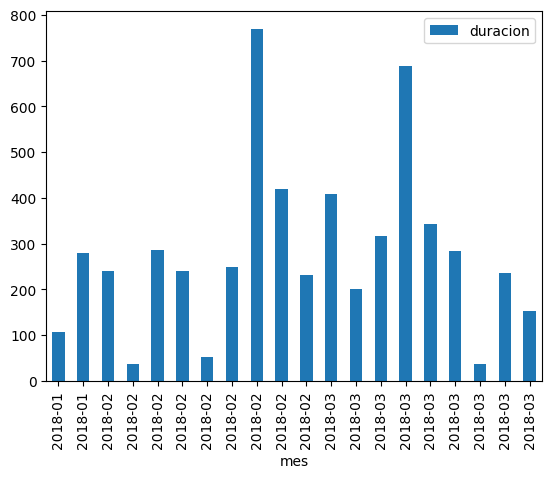

In [32]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
call_surf = total_2[total_2['plan'] == 'surf']
call_surf_g = call_surf.head(20).plot(x='mes', y='duracion',kind='bar')
call_surf_g      

Grafia de los planes surf.

<Axes: xlabel='mes'>

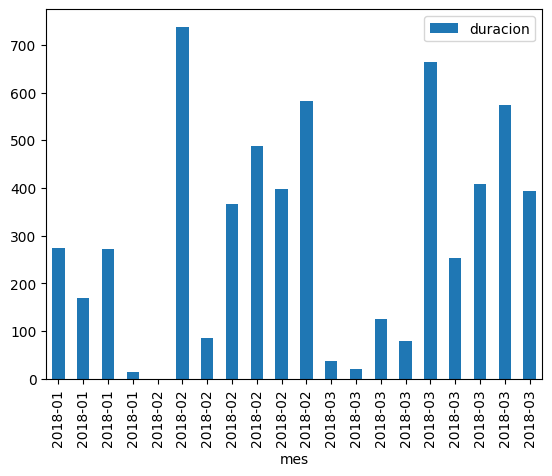

In [33]:
call_ultimate = total_2[total_2['plan']=='ultimate']
call_ultimate_G = call_ultimate.head(20).plot(x='mes', y='duracion',kind='bar')
call_ultimate_G   

Trasabilidad de usuarios del plan ultimate.

<Axes: title={'center': 'duracion'}, xlabel='mes'>

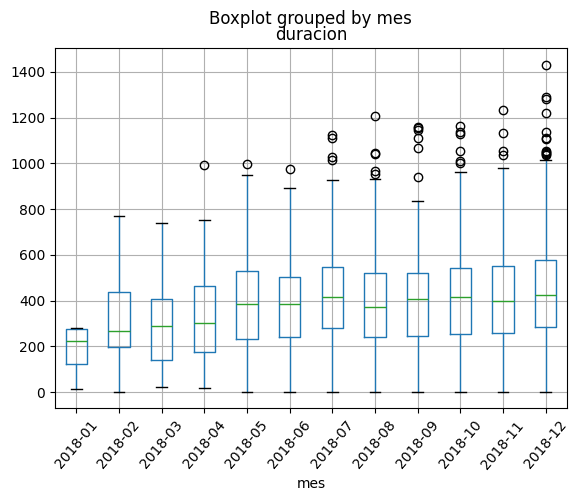

In [34]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

total_2.boxplot('duracion', by='mes',rot=50)


Tiempo promedio de duracion de las llamadas.

En la grafica de cajas observamos la comparacion por mes.

In [35]:
# Calcula la media y la varianza de la duración mensual de llamadas.

print('La media de duracion es: ',total_2['duracion'].mean())
print()
print('La varianza de la duracionde llamadas es: ',np.var(total_2['duracion']))

La media de duracion es:  405.2116266899259

La varianza de la duracionde llamadas es:  49878.43625112623


<Axes: title={'center': 'duracion'}, xlabel='mes'>

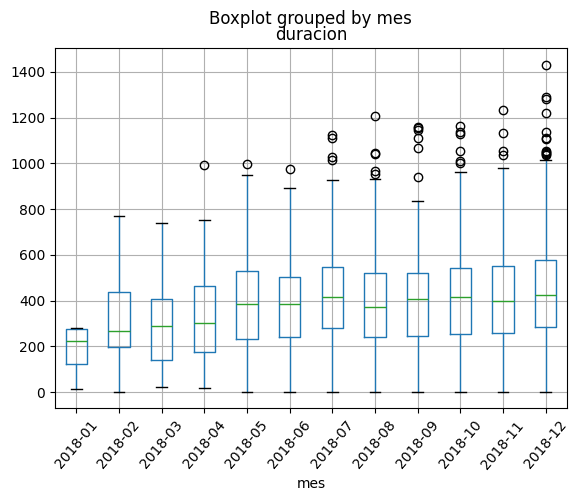

In [36]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

llamadas = total_2.boxplot('duracion', by='mes',rot=50)
llamadas

La duracion media de las llamadas es de alrededor de 400

### Mensajes

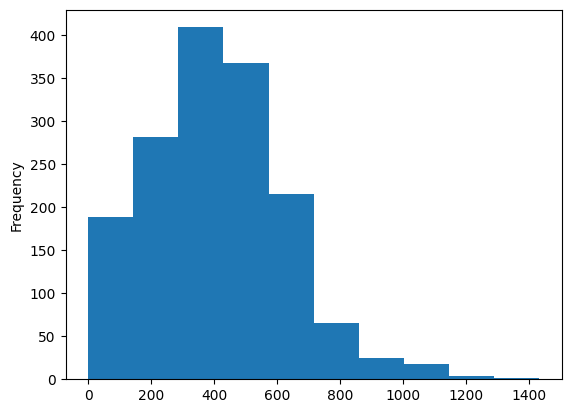

In [37]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
mensajes = total_2[total_2['plan']=='surf']
mensajes_s = mensajes['duracion'].plot(kind='hist')                

Tenemos la cantidad de mensajes enviados por usuarios plan surf.

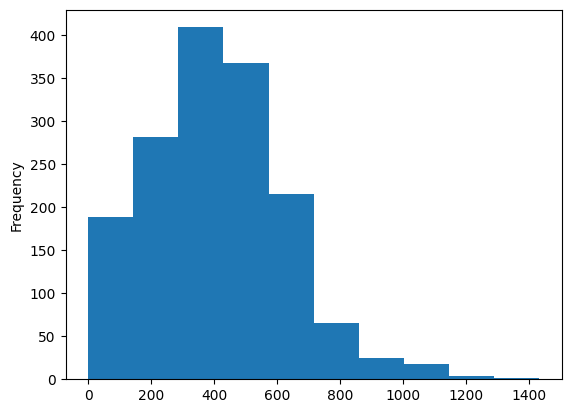

In [38]:
mensajes_ = total_2[total_2['plan']=='ultimate']
mensajes_u = mensajes['duracion'].plot(kind='hist')  

Mensajes enviados por usuarios plan ultmimate.

### Internet

<Axes: ylabel='Frequency'>

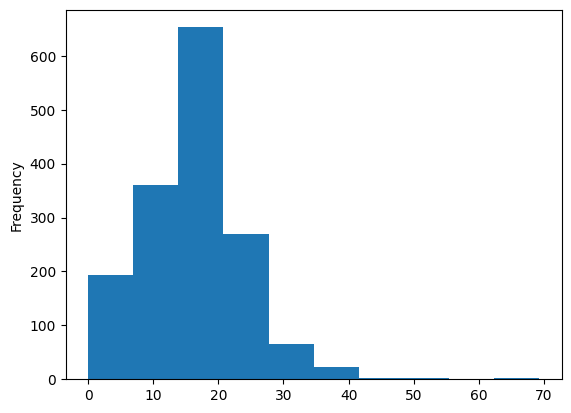

In [39]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

inter = total_2[total_2['plan']=='surf']
inter['total_mb_used'].plot(kind='hist')

Uso de internet de usuarios del plan surf.

<Axes: ylabel='Frequency'>

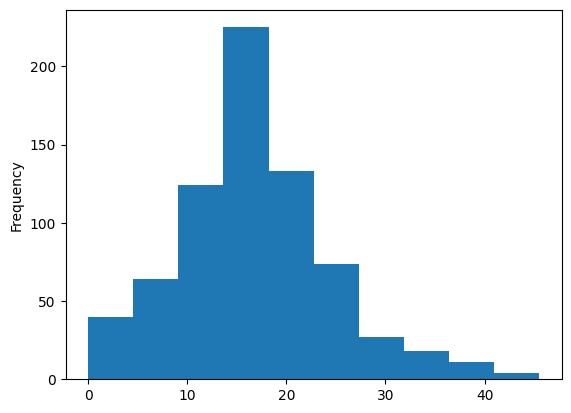

In [40]:
inter2 = total_2[total_2['plan']=='ultimate']
inter2['total_mb_used'].plot(kind='hist')

Uso de internet de usuarios del plan ultimate.

## Ingreso

In [41]:
ingresos = total_3['pago'].plot(kind='hist')

ingresos

TypeError: 'NoneType' object is not subscriptable

## Prueba las hipótesis estadísticas

In [ ]:
# Prueba las hipótesis

plan_surf = total_2[total_2['plan'].isin(['surf'])]['pago'] 
plan_ult = total_2[total_2['plan'].isin(['ultimate'])]['pago']

alpha=0.5

planes = st.ttest_ind(plan_surf, plan_ult, equal_var=False)
print(planes)

if planes.pvalue < alpha:
    print('Rechazamos la hipótesis nula. Hay evidencia suficiente para decir que los ingresos promedio son diferentes')
else:
    print('No rechazamos la hipótesis nula. No hay evidencia suficiente para decir que los ingresos promedio son diferentes ')

TtestResult(statistic=np.float64(-548.0857760027836), pvalue=np.float64(0.0), df=np.float64(1572.0000000000002))
Rechazamos la hipótesis nula. Hay evidencia suficiente para decir que los ingresos promedio son diferentes


c:\Users\jonathan.arrona\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
p = total_2[total_2['plan']=='surf']
print('El promedio surf es: ',p['pago'].mean())

u = total_2[total_2['plan']=='ultimate']
print
('El promedio ult es: ',u['pago'].mean())

El promedio surf es:  21.675089383343934


('El promedio ult es: ', np.float64(70.0))

In [ ]:
# Prueba las hipótesis


region_in = total_2[total_2['city'].str.contains('NY-NJ')]['pago'] 
others_regions = total_2[~total_2['city'].isin(['NY-NJ'])]['pago']

alpha=0.5

prueba = st.ttest_ind(region_in, others_regions, equal_var=False)
print(prueba)

if prueba.pvalue < alpha:
    print('Rechazamos la hipótesis nula. Hay evidencia suficiente para decir que los ingresos promedio son diferentes')
else:
    print('No rechazamos la hipótesis nula. No hay evidencia suficiente para decir que los ingresos promedio son diferentes ')

TtestResult(statistic=np.float64(-6.6665784720405865), pvalue=np.float64(6.140665859723568e-11), df=np.float64(576.0060765643374))
Rechazamos la hipótesis nula. Hay evidencia suficiente para decir que los ingresos promedio son diferentes


Conclusion:
    
    Hay un gran porcentaje de ganancia con los usuarios del plan surf, ya que tienen muchos excedentes en minutos y mensajes, aqui la recomendacion podria ser reducir un pocolos beneficios del plan ultimate para lograr tener excedentes y tener un plan intermedio y de esa manera los usuarios pueden tener mas opciones y captar mas usuarios.